In [1]:
import seaborn as sns
from sklearn.datasets import make_blobs

In [2]:
X, y = make_blobs(
    n_samples=1000, 
    n_features=2,  
    centers=4,
    random_state = 42
)

<Axes: >

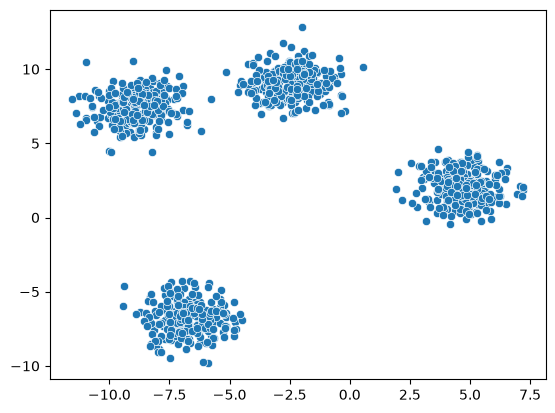

In [3]:
# Visualize

sns.scatterplot(x = X[:,0], y=X[:,1])

In [4]:
# K-means Clustering

from sklearn.cluster import KMeans 

In [5]:
K = 4

kmeans = KMeans(
    n_clusters = K,
    random_state = 42
)

In [6]:
labels = kmeans.fit_predict(X)

<Axes: >

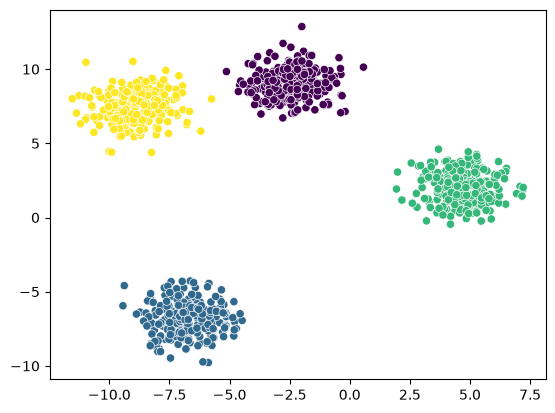

In [7]:
sns.scatterplot(x = X[:,0], y=X[:,1], c = labels)

### How to Choose k value 

In [8]:
# 1) Elbow method (Manual way)

wcss = []

for k in range(1,21):
    kmeans = KMeans(n_clusters = k)
    kmeans.fit_predict(X)
    wcss.append(kmeans.inertia_)

<Axes: >

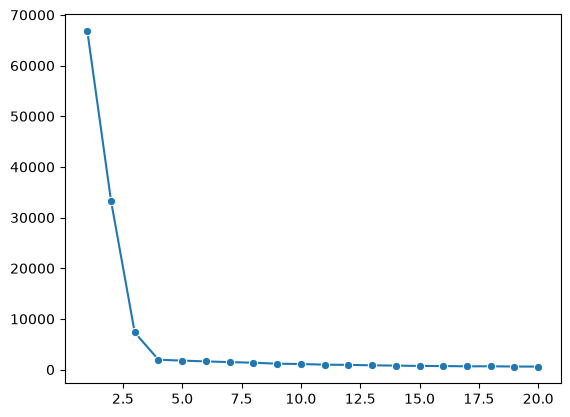

In [9]:
sns.lineplot(x=range(1,21), y=wcss, marker="o")

In [10]:
# kneed module (Automatic way)

!pip install kneed

In [11]:
from kneed import KneeLocator

knee = KneeLocator(range(1,21), wcss, curve = "convex", direction = "decreasing")
print("optimal k value is: ",knee.elbow)

optimal k value is:  4


### 2) Silhoutte score

In [12]:
from sklearn.metrics import silhouette_score

ss = []

for k in range(2,21):
    kmeans = KMeans(n_clusters=k)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    
    ss.append(score)

<Axes: >

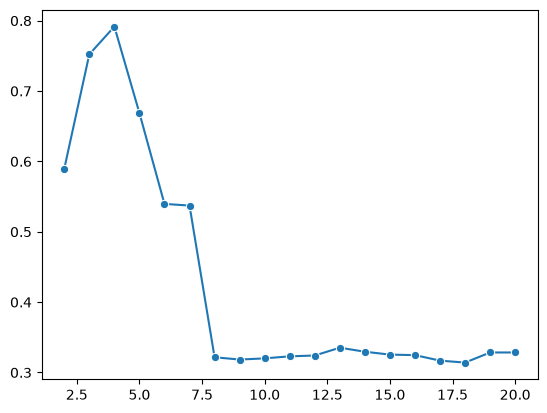

In [13]:
# plot - k and silhouette_score

sns.lineplot(x=range(2,21), y=ss, marker = "o")

### The highest value is 4 that means k = 4